In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted!")

Mounted at /content/drive
✅ Drive mounted!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8')

meter_map = {0:'Electricity', 1:'Chilled Water',
             2:'Steam', 3:'Hot Water'}

print("✅ Libraries imported!")

✅ Libraries imported!


In [ ]:
df = pd.read_parquet(
    '/content/drive/MyDrive/hvac_project/merged_energy_data.parquet'
)

print(f"✅ Raw data loaded!")
print(f"   Shape   : {df.shape}")
print(f"   Columns : {df.columns.tolist()}")

✅ Raw data loaded!
   Shape   : (20216100, 16)
   Columns : ['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id', 'primary_use', 'square_feet', 'year_built', 'floor_count', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed']


In [ ]:
df = df[
    (df['site_id'].isin([14, 15])) &
    (df['meter'].isin([0, 1, 2, 3]))
].copy()

df = df.reset_index(drop=True)

print(f"✅ Filtered to Sites 14 & 15, All 4 Meters!")
print(f"   Shape : {df.shape}")
print(f"\nRows per meter:")
for meter_id, meter_name in meter_map.items():
    count = len(df[df['meter'] == meter_id])
    print(f"  {meter_name:15} : {count:,}")

✅ Filtered to Sites 14 & 15, All 4 Meters!
   Shape : (4316560, 16)

Rows per meter:
  Electricity     : 1,731,963
  Chilled Water   : 1,207,968
  Steam           : 865,568
  Hot Water       : 511,061


In [ ]:
print("=" * 50)
print("STEP 1 — UNDERSTANDING THE DATA")
print("=" * 50)

print(f"\nRows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nBasic Statistics:\n{df.describe()}")

STEP 1 — UNDERSTANDING THE DATA

Rows    : 4,316,560
Columns : 16

Data Types:
building_id                    int64
meter                          int64
timestamp             datetime64[ns]
meter_reading                float64
site_id                        int64
primary_use                   object
square_feet                    int64
year_built                   float64
floor_count                  float64
air_temperature              float64
cloud_coverage               float64
dew_temperature              float64
precip_depth_1_hr            float64
sea_level_pressure           float64
wind_direction               float64
wind_speed                   float64
dtype: object

First 5 rows:
   building_id  meter  timestamp  meter_reading  site_id primary_use  \
0         1223      0 2016-01-01          79.85       14      Office   
1         1223      1 2016-01-01         174.44       14      Office   
2         1223      3 2016-01-01         436.64       14      Office   
3         12

STEP 2 — MISSING VALUE ANALYSIS
                    Missing Count  Missing %
floor_count               4316560     100.00
year_built                2649886      61.39
cloud_coverage            1884609      43.66
precip_depth_1_hr         1500443      34.76
sea_level_pressure         222141       5.15
wind_direction             205691       4.77
wind_speed                  85673       1.98
dew_temperature             74114       1.72
air_temperature             73379       1.70


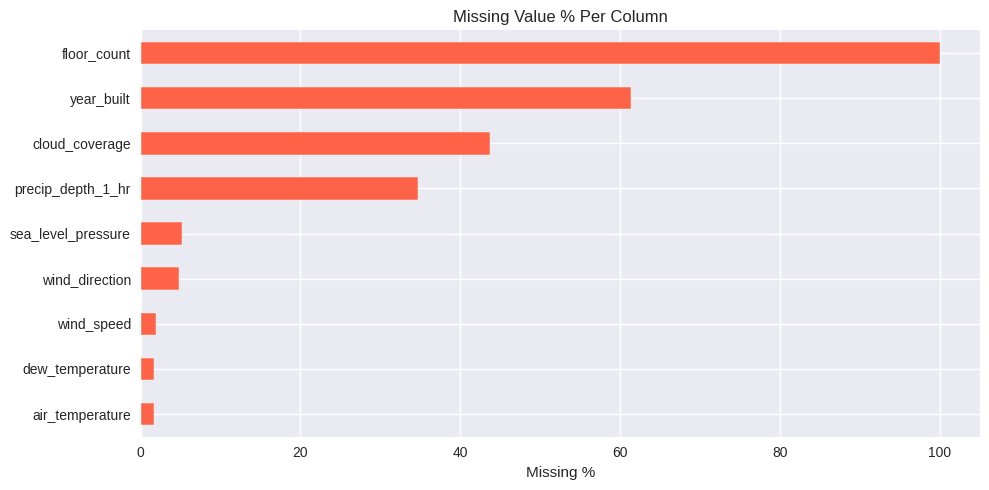

In [ ]:
print("=" * 50)
print("STEP 2 — MISSING VALUE ANALYSIS")
print("=" * 50)

missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing %'     : missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

plt.figure(figsize=(10, 5))
missing_pct[missing_pct > 0].sort_values()\
    .plot(kind='barh', color='tomato', edgecolor='white')
plt.title('Missing Value % Per Column')
plt.xlabel('Missing %')
plt.tight_layout()
plt.show()

In [ ]:
# Drop columns with too many missing values
cols_to_drop = ['floor_count', 'year_built']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print(f"✅ Dropped unreliable columns: {cols_to_drop}")
print(f"   New shape: {df.shape}")

✅ Dropped unreliable columns: ['floor_count', 'year_built']
   New shape: (4316560, 14)


In [ ]:
# Forward fill time-based weather columns
weather_cols = ['air_temperature', 'dew_temperature',
                'wind_speed', 'wind_direction', 'sea_level_pressure']
df[weather_cols] = df[weather_cols].fillna(method='ffill')

# Cloud coverage — forward fill then fill with 0
df['cloud_coverage'] = df['cloud_coverage']\
    .fillna(method='ffill').fillna(0)

# Precipitation — fill with 0
df['precip_depth_1_hr'] = df['precip_depth_1_hr'].fillna(0)

print(f"✅ Missing values handled!")
print(f"   Remaining missing: {df.isnull().sum().sum()}")

✅ Missing values handled!
   Remaining missing: 2615


In [ ]:
# These columns add noise without useful signal
irrelevant_cols = ['wind_direction', 'precip_depth_1_hr', 'cloud_coverage']
df = df.drop(columns=irrelevant_cols)

print(f"✅ Dropped irrelevant columns: {irrelevant_cols}")
print(f"   Remaining columns: {df.columns.tolist()}")

✅ Dropped irrelevant columns: ['wind_direction', 'precip_depth_1_hr', 'cloud_coverage']
   Remaining columns: ['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id', 'primary_use', 'square_feet', 'air_temperature', 'dew_temperature', 'sea_level_pressure', 'wind_speed']


In [ ]:
print("=" * 50)
print("STEP 3 — DUPLICATE CHECK")
print("=" * 50)

total_dups = df.duplicated().sum()
key_dups   = df.duplicated(
    subset=['building_id', 'meter', 'timestamp']
).sum()

print(f"Total duplicates     : {total_dups:,}")
print(f"Key duplicates       : {key_dups:,}")

if total_dups > 0:
    df = df.drop_duplicates()
    print(f"✅ Duplicates removed! New shape: {df.shape}")
else:
    print("✅ No duplicates found!")

STEP 3 — DUPLICATE CHECK
Total duplicates     : 0
Key duplicates       : 0
✅ No duplicates found!


In [ ]:
print("=" * 50)
print("STEP 4 — NEGATIVE READINGS")
print("=" * 50)

neg_count = (df['meter_reading'] < 0).sum()
print(f"Negative readings : {neg_count:,}")

if neg_count > 0:
    df = df[df['meter_reading'] >= 0]
    print(f"✅ Removed! New shape: {df.shape}")
else:
    print("✅ No negative readings!")

STEP 4 — NEGATIVE READINGS
Negative readings : 0
✅ No negative readings!


STEP 5 — ZERO READING ANALYSIS

Overall zero %: 8.26%

Zero % per meter type:
  Electricity     : 3.06%
  Chilled Water   : 12.96%
  Steam           : 8.29%
  Hot Water       : 14.73%


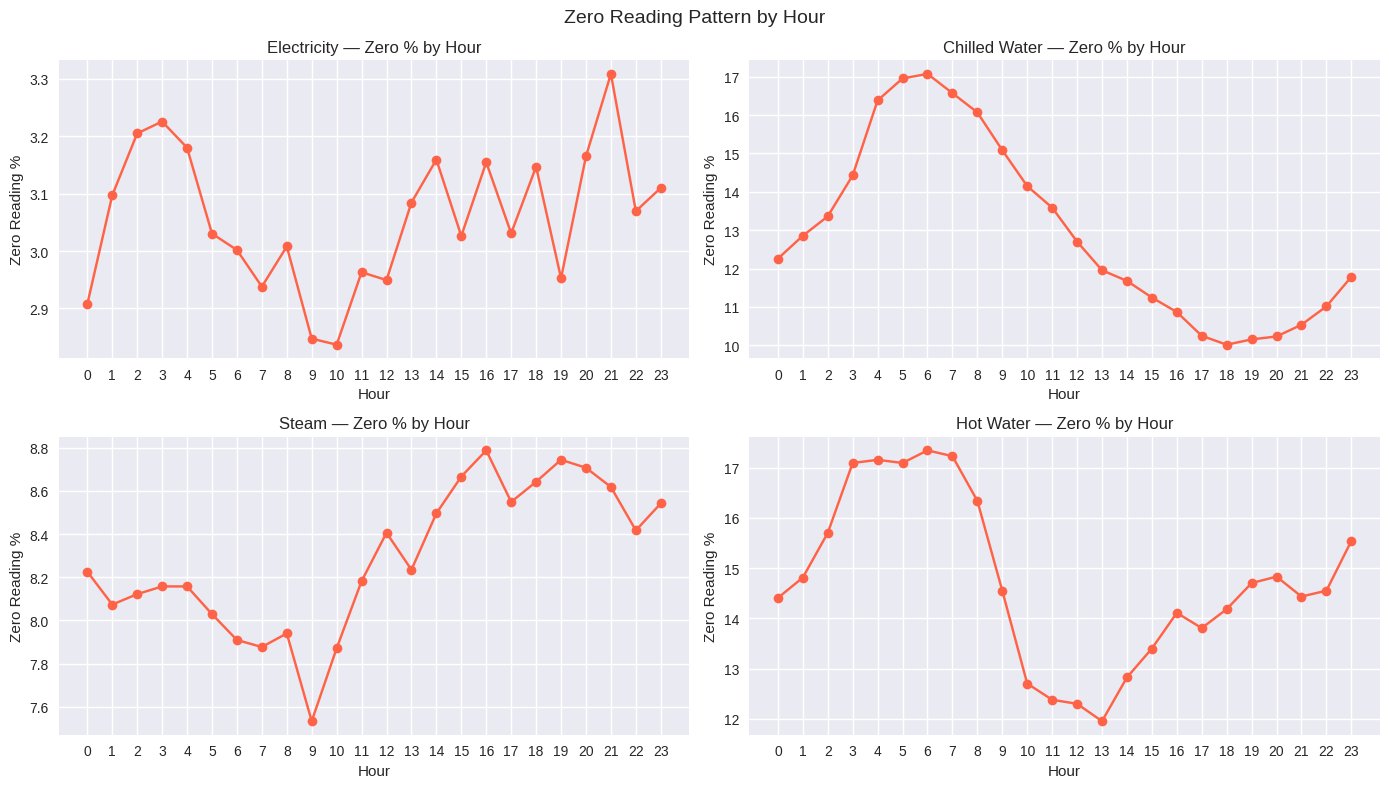

In [ ]:
print("=" * 50)
print("STEP 5 — ZERO READING ANALYSIS")
print("=" * 50)

# Ensure 'hour' column is available for analysis
if 'hour' not in df.columns:
    df['hour'] = df['timestamp'].dt.hour

print(f"\nOverall zero %: {(df['meter_reading']==0).mean()*100:.2f}%")
print("\nZero % per meter type:")

for meter_id, meter_name in meter_map.items():
    subset   = df[df['meter'] == meter_id]
    zero_pct = (subset['meter_reading'] == 0).mean() * 100
    print(f"  {meter_name:15} : {zero_pct:.2f}%")

# Visualize zeros per meter
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, (meter_id, meter_name) in enumerate(meter_map.items()):
    ax     = axes[i//2][i%2]
    subset = df[df['meter'] == meter_id]
    zero_by_hour = subset.groupby('hour').apply(
        lambda x: (x['meter_reading']==0).mean()*100
    )
    ax.plot(zero_by_hour.index, zero_by_hour.values,
            marker='o', color='tomato')
    ax.set_title(f'{meter_name} — Zero % by Hour')
    ax.set_xlabel('Hour')
    ax.set_ylabel('Zero Reading %')
    ax.set_xticks(range(0, 24))

plt.suptitle('Zero Reading Pattern by Hour', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 50)
print("STEP 6 — OUTLIER ANALYSIS")
print("=" * 50)

hard_caps = {0: 1629.61, 1: 5449.22, 2: 5449.22, 3: 3676.39}

for meter_id, meter_name in meter_map.items():
    subset = df[df['meter'] == meter_id]['meter_reading']
    Q1     = subset.quantile(0.25)
    Q3     = subset.quantile(0.75)
    IQR    = Q3 - Q1
    upper  = Q3 + 1.5 * IQR
    outliers = (subset > upper).sum()

    print(f"\n{meter_name}:")
    print(f"  Min       : {subset.min():.2f}")
    print(f"  Max       : {subset.max():.2f}")
    print(f"  Mean      : {subset.mean():.2f}")
    print(f"  Median    : {subset.median():.2f}")
    print(f"  IQR Upper : {upper:.2f}")
    print(f"  Outliers  : {outliers:,} ({outliers/len(subset)*100:.2f}%)")
    print(f"  Hard Cap  : {hard_caps[meter_id]}")

STEP 6 — OUTLIER ANALYSIS

Electricity:
  Min       : 0.00
  Max       : 1989.07
  Mean      : 162.04
  Median    : 86.84
  IQR Upper : 444.38
  Outliers  : 162,271 (9.37%)
  Hard Cap  : 1629.61

Chilled Water:
  Min       : 0.00
  Max       : 33059.70
  Mean      : 656.04
  Median    : 99.13
  IQR Upper : 1321.55
  Outliers  : 152,601 (12.63%)
  Hard Cap  : 5449.22

Steam:
  Min       : 0.00
  Max       : 31799.00
  Mean      : 1010.40
  Median    : 424.68
  IQR Upper : 2624.43
  Outliers  : 81,722 (9.44%)
  Hard Cap  : 5449.22

Hot Water:
  Min       : 0.00
  Max       : 26860.60
  Mean      : 490.49
  Median    : 209.63
  IQR Upper : 1445.03
  Outliers  : 34,984 (6.85%)
  Hard Cap  : 3676.39


In [ ]:
hard_caps = {0: 1629.61, 1: 5449.22, 2: 5449.22, 3: 3676.39}

for meter_id, cap in hard_caps.items():
    mask = df['meter'] == meter_id
    df.loc[mask, 'meter_reading'] = \
        df.loc[mask, 'meter_reading'].clip(upper=cap)
    print(f"  {meter_map[meter_id]:15} → capped at {cap}")

print(f"\n✅ Hard caps applied!")
print(f"\nMax per meter after capping:")
for meter_id, meter_name in meter_map.items():
    max_val = df[df['meter'] == meter_id]['meter_reading'].max()
    print(f"  {meter_name:15} : {max_val:.2f}")

  Electricity     → capped at 1629.61
  Chilled Water   → capped at 5449.22
  Steam           → capped at 5449.22
  Hot Water       → capped at 3676.39

✅ Hard caps applied!

Max per meter after capping:
  Electricity     : 1629.61
  Chilled Water   : 5449.22
  Steam           : 5449.22
  Hot Water       : 3676.39


STEP 7 — TARGET VARIABLE ANALYSIS


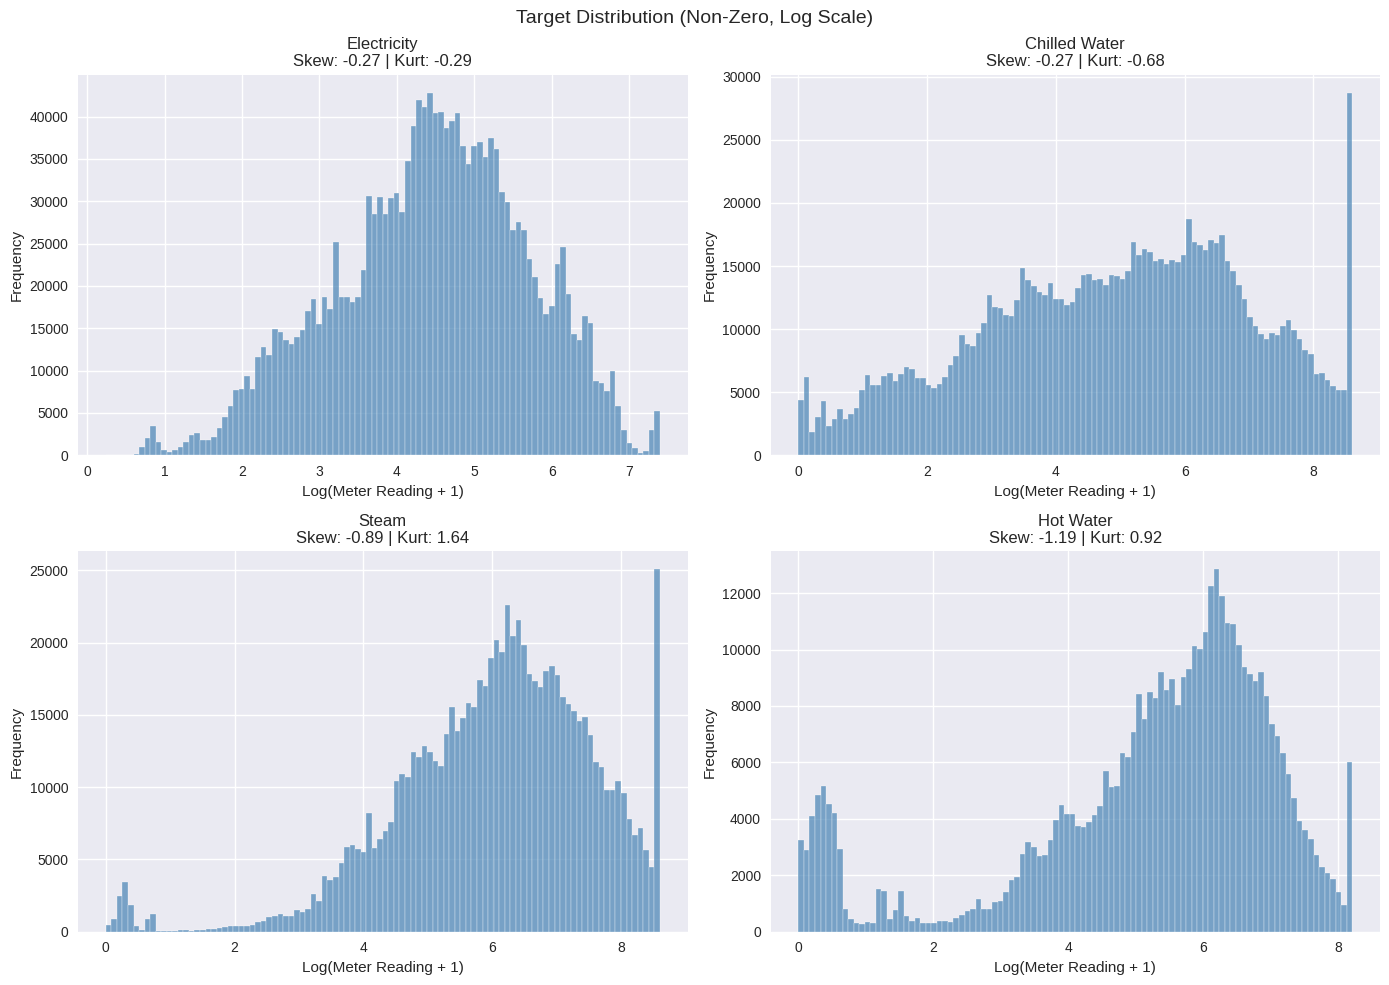

In [ ]:
print("=" * 50)
print("STEP 7 — TARGET VARIABLE ANALYSIS")
print("=" * 50)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (meter_id, meter_name) in enumerate(meter_map.items()):
    ax     = axes[i//2][i%2]
    subset = df[df['meter'] == meter_id]['meter_reading']
    subset_nonzero = subset[subset > 0]

    ax.hist(np.log1p(subset_nonzero), bins=100,
            color='steelblue', edgecolor='white', alpha=0.7)
    ax.set_title(f'{meter_name}\n'
                 f'Skew: {np.log1p(subset_nonzero).skew():.2f} | '
                 f'Kurt: {np.log1p(subset_nonzero).kurtosis():.2f}')
    ax.set_xlabel('Log(Meter Reading + 1)')
    ax.set_ylabel('Frequency')

plt.suptitle('Target Distribution (Non-Zero, Log Scale)', fontsize=14)
plt.tight_layout()
plt.show()

STEP 8 — TIME BASED ANALYSIS


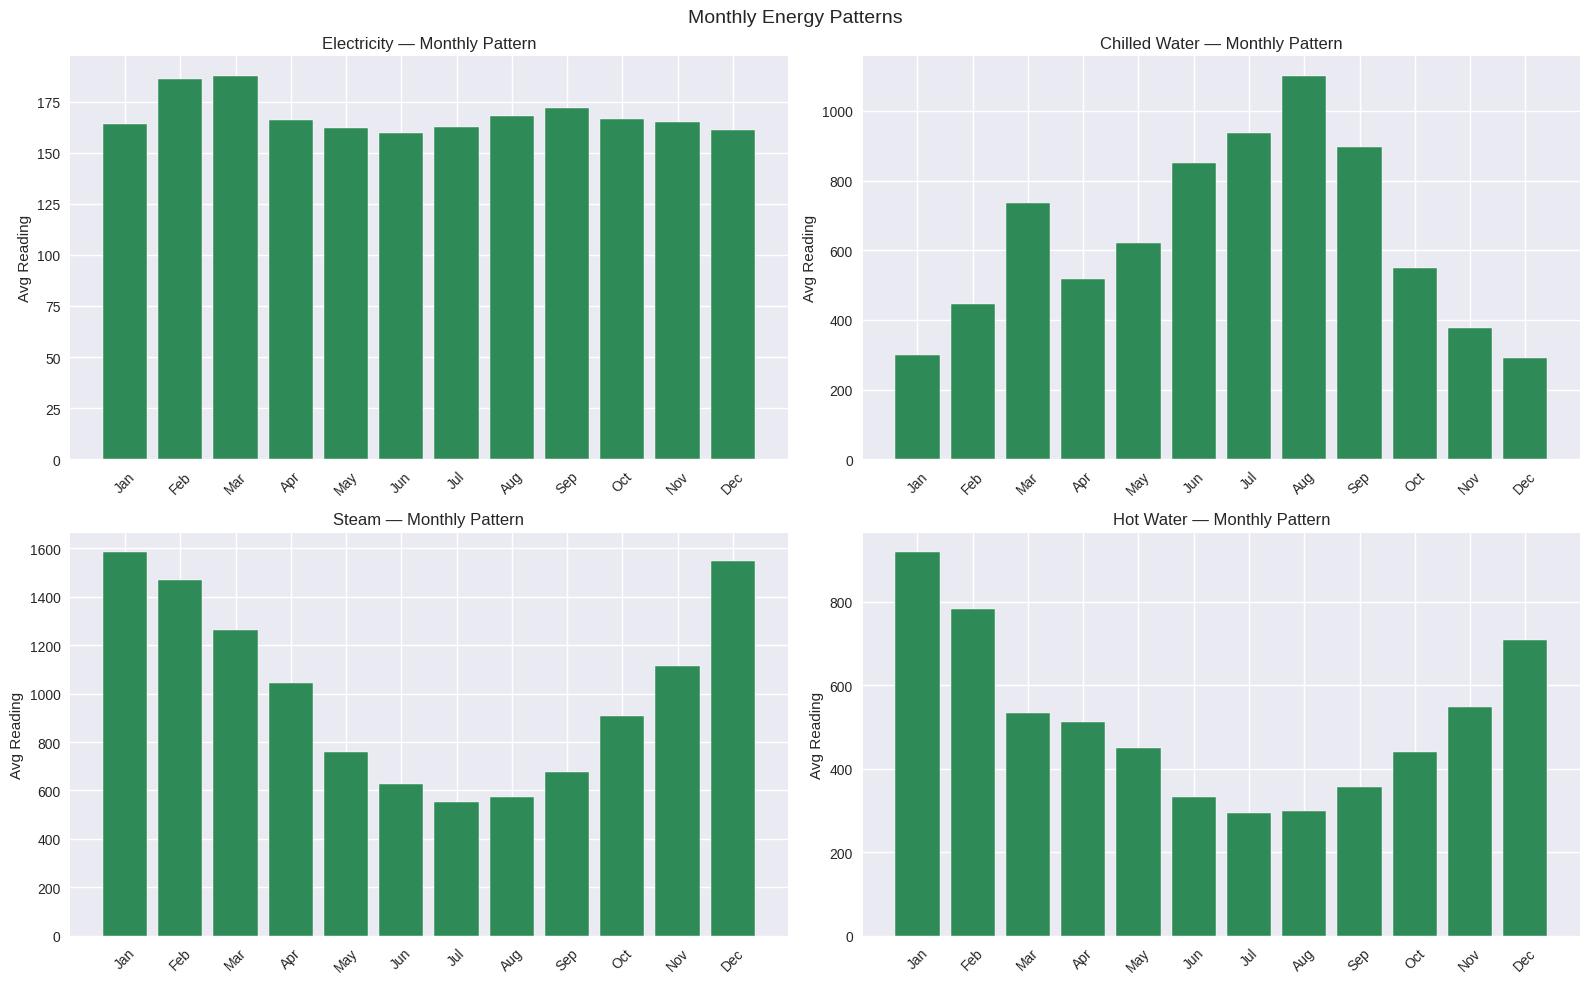

In [ ]:
print("=" * 50)
print("STEP 8 — TIME BASED ANALYSIS")
print("=" * 50)

month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr',
               5:'May', 6:'Jun', 7:'Jul', 8:'Aug',
               9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

# Add time features if not present
if 'hour' not in df.columns:
    df['hour']    = df['timestamp'].dt.hour
if 'month' not in df.columns:
    df['month']   = df['timestamp'].dt.month
if 'weekday' not in df.columns:
    df['weekday'] = df['timestamp'].dt.dayofweek

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i, (meter_id, meter_name) in enumerate(meter_map.items()):
    ax     = axes[i//2][i%2]
    subset = df[(df['meter'] == meter_id) & (df['meter_reading'] > 0)]
    monthly = subset.groupby('month')['meter_reading'].mean()
    ax.bar(monthly.index, monthly.values,
           color='seagreen', edgecolor='white')
    ax.set_title(f'{meter_name} — Monthly Pattern')
    ax.set_xticks(list(month_names.keys()))
    ax.set_xticklabels(list(month_names.values()), rotation=45)
    ax.set_ylabel('Avg Reading')

plt.suptitle('Monthly Energy Patterns', fontsize=14)
plt.tight_layout()
plt.show()

STEP 9 — WEATHER vs ENERGY


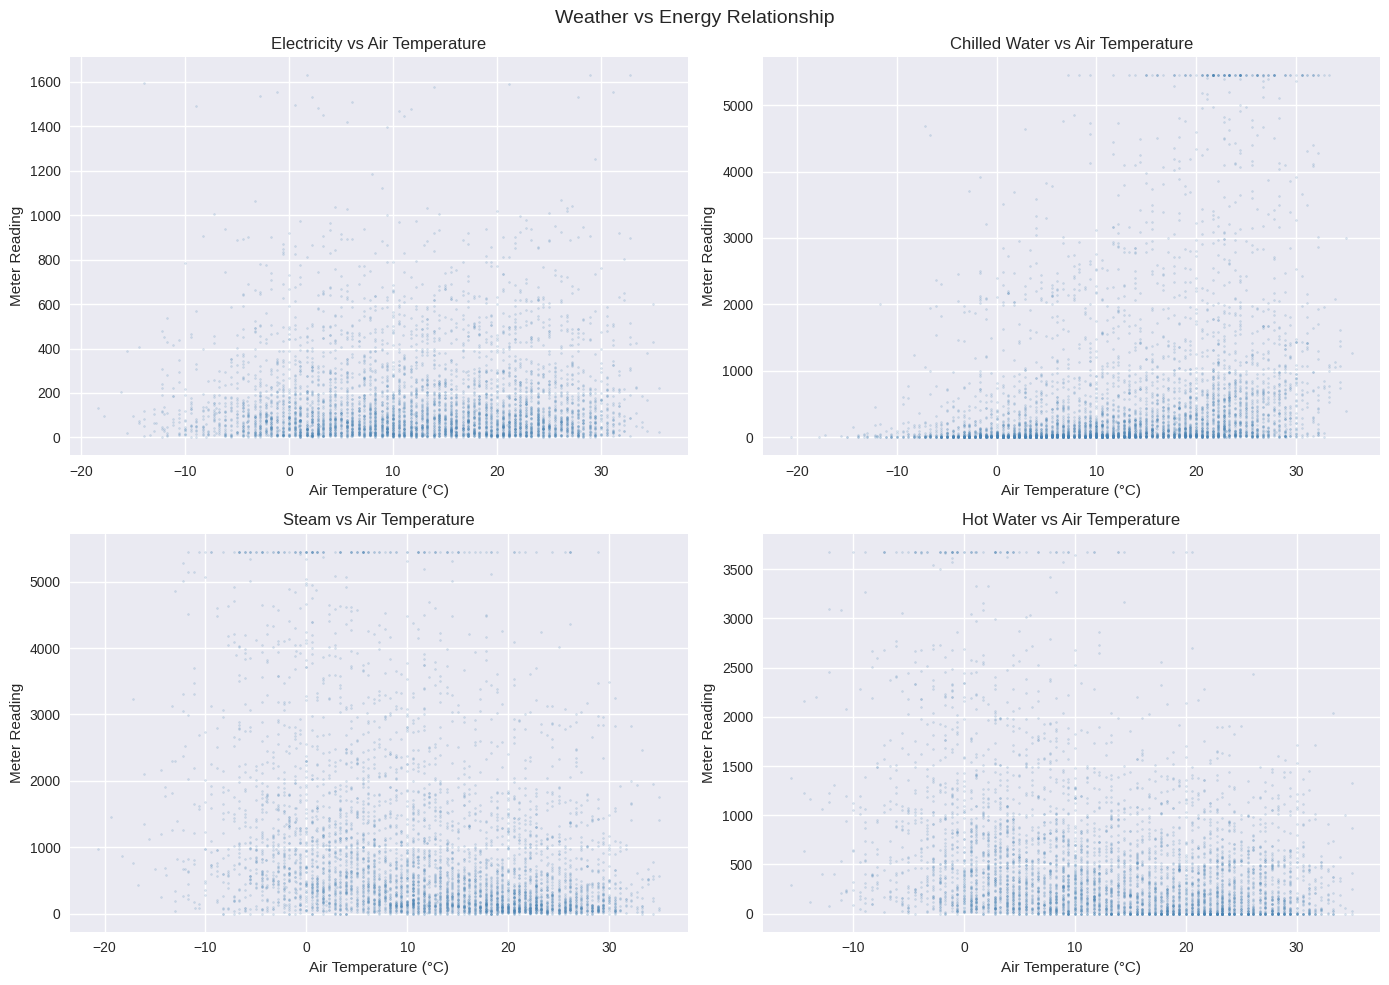

In [ ]:
print("=" * 50)
print("STEP 9 — WEATHER vs ENERGY")
print("=" * 50)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (meter_id, meter_name) in enumerate(meter_map.items()):
    ax     = axes[i//2][i%2]
    subset = df[
        (df['meter'] == meter_id) &
        (df['meter_reading'] > 0)
    ].sample(min(5000, len(df[df['meter'] == meter_id])),
              random_state=42)
    ax.scatter(subset['air_temperature'],
               subset['meter_reading'],
               alpha=0.2, s=2, color='steelblue')
    ax.set_title(f'{meter_name} vs Air Temperature')
    ax.set_xlabel('Air Temperature (°C)')
    ax.set_ylabel('Meter Reading')

plt.suptitle('Weather vs Energy Relationship', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
df['hour']       = df['timestamp'].dt.hour
df['month']      = df['timestamp'].dt.month
df['weekday']    = df['timestamp'].dt.dayofweek
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)
df['meter_name'] = df['meter'].map(meter_map)

print("✅ Time features added!")
print(f"   hour, month, weekday, is_weekend, meter_name")

✅ Time features added!
   hour, month, weekday, is_weekend, meter_name


In [ ]:
# Cooling Degree Days and Heating Degree Days
# Base temperature 18°C — standard HVAC reference
base_temp = 18
df['CDD'] = np.maximum(df['air_temperature'] - base_temp, 0)
df['HDD'] = np.maximum(base_temp - df['air_temperature'], 0)

print("✅ CDD and HDD features added!")
print(f"\nCDD stats:")
print(f"  Mean : {df['CDD'].mean():.2f}")
print(f"  Max  : {df['CDD'].max():.2f}")
print(f"\nHDD stats:")
print(f"  Mean : {df['HDD'].mean():.2f}")
print(f"  Max  : {df['HDD'].max():.2f}")

✅ CDD and HDD features added!

CDD stats:
  Mean : 2.02
  Max  : 17.60

HDD stats:
  Mean : 7.76
  Max  : 41.90


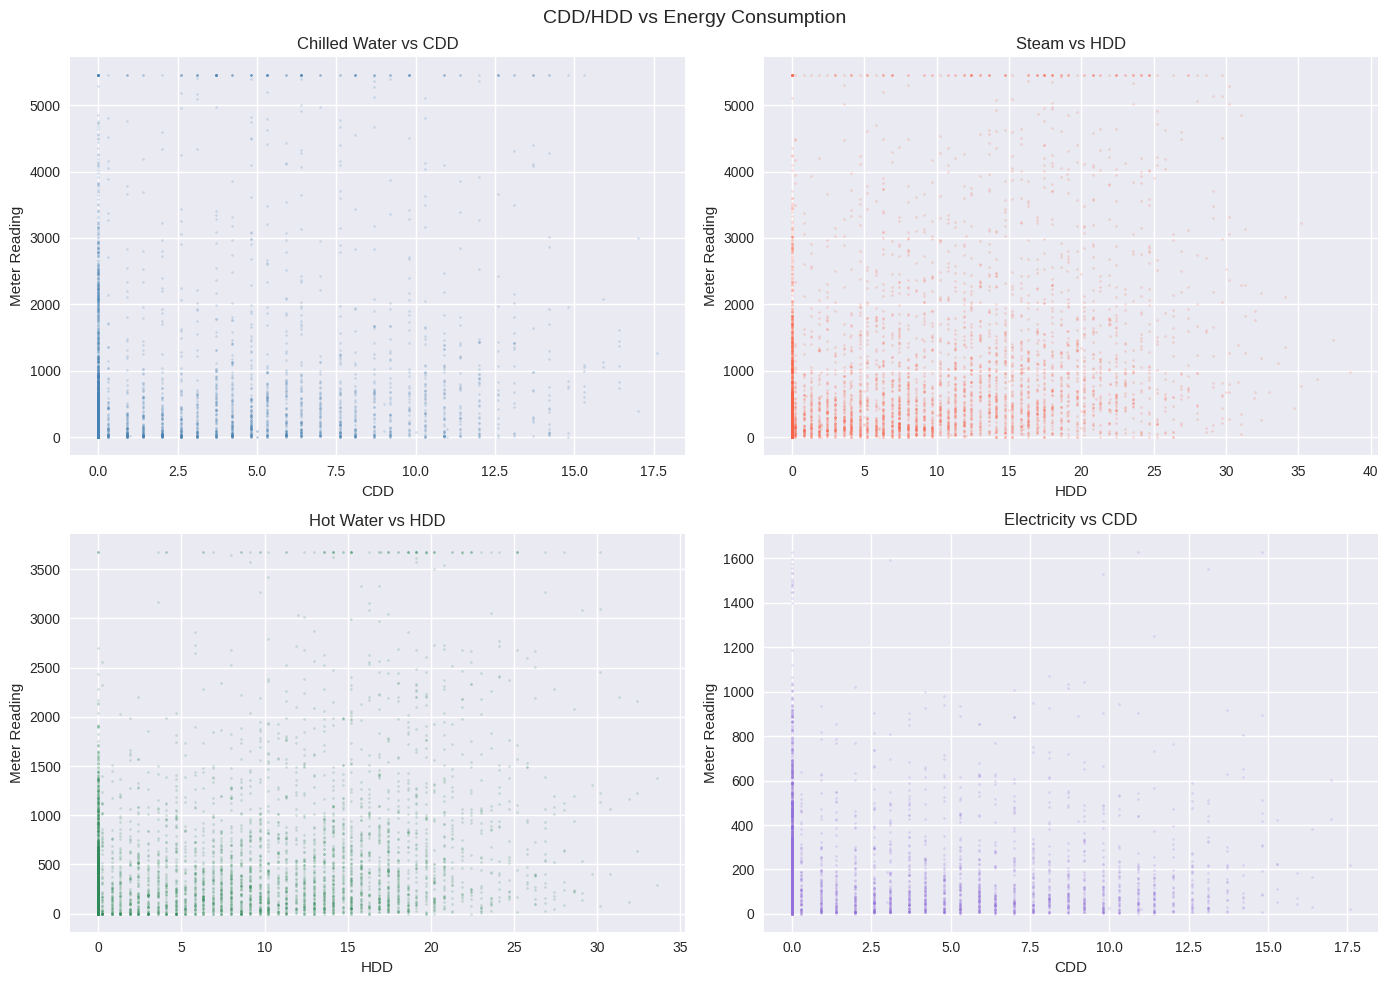

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_configs = [
    (1, 'CDD', 'Chilled Water vs CDD', 'steelblue'),
    (2, 'HDD', 'Steam vs HDD', 'tomato'),
    (3, 'HDD', 'Hot Water vs HDD', 'seagreen'),
    (0, 'CDD', 'Electricity vs CDD', 'mediumpurple'),
]

for i, (meter_id, weather_feat, title, color) in enumerate(plot_configs):
    ax     = axes[i//2][i%2]
    subset = df[
        (df['meter'] == meter_id) &
        (df['meter_reading'] > 0)
    ].sample(min(5000, len(df[df['meter']==meter_id])),
              random_state=42)
    ax.scatter(subset[weather_feat], subset['meter_reading'],
               alpha=0.2, s=2, color=color)
    ax.set_title(title)
    ax.set_xlabel(weather_feat)
    ax.set_ylabel('Meter Reading')

plt.suptitle('CDD/HDD vs Energy Consumption', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
df['meter_reading_log'] = np.log1p(df['meter_reading'])

print("✅ Log transformed target added!")
print(f"\nSkewness before log : {df['meter_reading'].skew():.4f}")
print(f"Skewness after log  : {df['meter_reading_log'].skew():.4f}")

✅ Log transformed target added!

Skewness before log : 3.5764
Skewness after log  : -0.5900


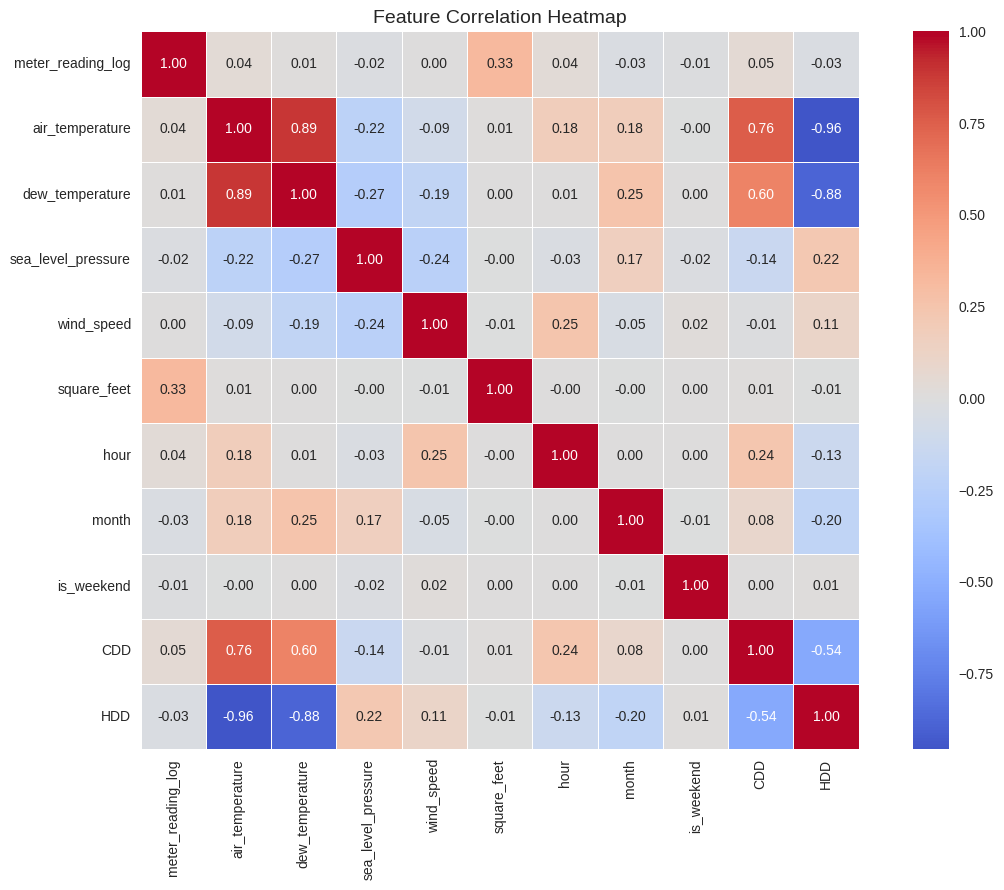


Top correlations with meter_reading_log:
square_feet           0.33
CDD                   0.05
air_temperature       0.04
hour                  0.04
month                -0.03
HDD                  -0.03
sea_level_pressure   -0.02
dew_temperature       0.01
is_weekend           -0.01
wind_speed            0.00
Name: meter_reading_log, dtype: float64


In [ ]:
num_cols = ['meter_reading_log', 'air_temperature', 'dew_temperature',
            'sea_level_pressure', 'wind_speed', 'square_feet',
            'hour', 'month', 'is_weekend', 'CDD', 'HDD']

corr = df[num_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

print("\nTop correlations with meter_reading_log:")
print(corr['meter_reading_log']\
      .drop('meter_reading_log')\
      .sort_values(key=abs, ascending=False))

In [ ]:
print("=" * 50)
print("FINAL VERIFICATION")
print("=" * 50)

print(f"Shape          : {df.shape}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Negative vals  : {(df['meter_reading'] < 0).sum()}")
print(f"\nMax per meter:")
for meter_id, meter_name in meter_map.items():
    max_val = df[df['meter'] == meter_id]['meter_reading'].max()
    print(f"  {meter_name:15} : {max_val:.2f}")

print(f"\nColumns : {df.columns.tolist()}")

FINAL VERIFICATION
Shape          : (4316560, 19)
Missing values : 3138
Negative vals  : 0

Max per meter:
  Electricity     : 1629.61
  Chilled Water   : 5449.22
  Steam           : 5449.22
  Hot Water       : 3676.39

Columns : ['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id', 'primary_use', 'square_feet', 'air_temperature', 'dew_temperature', 'sea_level_pressure', 'wind_speed', 'hour', 'month', 'weekday', 'is_weekend', 'meter_name', 'CDD', 'HDD', 'meter_reading_log']


In [ ]:
output_path = '/content/drive/MyDrive/hvac_project/eda_final_v3.parquet'
df.to_parquet(output_path, index=False)

print("✅ Final EDA data saved!")
print(f"   Path    : {output_path}")
print(f"   Shape   : {df.shape}")

✅ Final EDA data saved!
   Path    : /content/drive/MyDrive/hvac_project/eda_final_v3.parquet
   Shape   : (4316560, 19)
